In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [2]:
import os
os.chdir('..')
os.chdir('..')
os.getcwd()

'/Users/ak/Documents/GitHub/rise-project/pair_trading'

In [3]:
import numpy as np, random, os
import pandas as pd
from models import xgboost

np.random.seed(42)
random.seed(42)
os.environ["PYTHONHASHSEED"] = "42"

stock_pairs = [('JNJ','AAPL'), 
         ('JNJ','MA'), 
         ('JNJ','GE'), 
         ('WMT','AAPL'), 
         ('WMT', 'MA'),
         ('WMT', 'GE'), 
         ('ABBV','AAPL'), 
         ('ABBV', 'MA'), 
         ('ABBV','GE')]

tickers = sorted(set([stock for pair in stock_pairs for stock in pair]))

stock_train_prices = pd.read_csv("stocks/stock_train_prices.csv", index_col = 0, parse_dates = True)
stock_test_prices = pd.read_csv("stocks/stock_test_prices.csv", index_col = 0, parse_dates = True)

train_prices = stock_train_prices[tickers].dropna()
test_prices = stock_test_prices[tickers].dropna()

In [4]:
pair_models, pair_betas, feature_cols = xgboost.grid_search(stock_pairs, train_prices, test_prices)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.2s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.5s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.5s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=6, min_child_weight=1; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, 

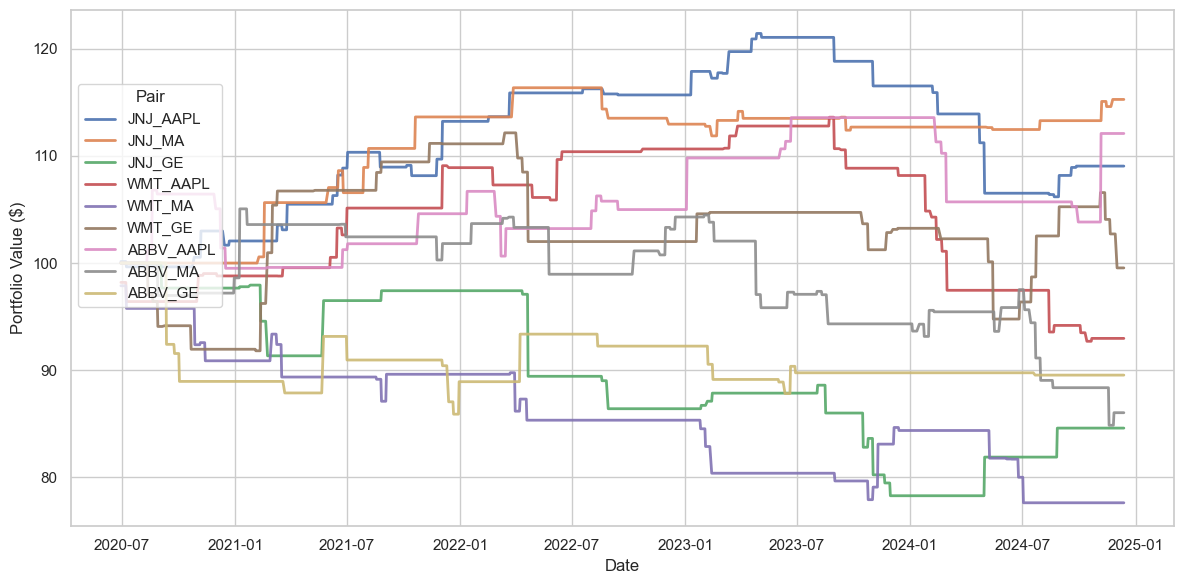

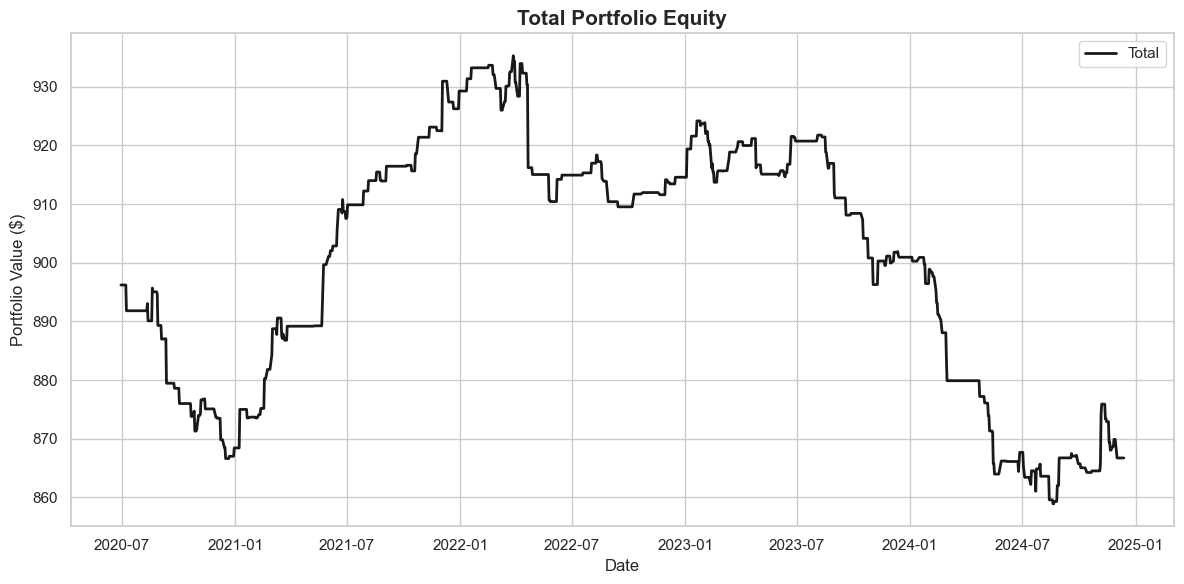

Summary
JNJ_AAPL: Final Value = $109.05, Total Return = 8.90%, Trades = 42
JNJ_MA: Final Value = $115.27, Total Return = 15.27%, Trades = 26
JNJ_GE: Final Value = $84.60, Total Return = -15.40%, Trades = 23
WMT_AAPL: Final Value = $92.97, Total Return = -5.32%, Trades = 37
WMT_MA: Final Value = $77.63, Total Return = -20.69%, Trades = 29
WMT_GE: Final Value = $99.55, Total Return = -0.45%, Trades = 37
ABBV_AAPL: Final Value = $112.09, Total Return = 12.09%, Trades = 29
ABBV_MA: Final Value = $86.04, Total Return = -13.96%, Trades = 44
ABBV_GE: Final Value = $89.54, Total Return = -10.46%, Trades = 19

Total Portfolio Performance
Initial Portfolio Value: $896.21
Final Portfolio Value:   $866.73
Total Return:            -3.29%

Sharpe Ratios
JNJ_AAPL: Sharpe Ratio = 0.45
JNJ_MA: Sharpe Ratio = 0.85
JNJ_GE: Sharpe Ratio = -0.51
WMT_AAPL: Sharpe Ratio = -0.22
WMT_MA: Sharpe Ratio = -0.87
WMT_GE: Sharpe Ratio = 0.02
ABBV_AAPL: Sharpe Ratio = 0.41
ABBV_MA: Sharpe Ratio = -0.47
ABBV_GE: Sharp

In [5]:
xgboost.run_simulation(stock_pairs, test_prices, pair_models, feature_cols, pair_betas)